# TileDB-SOMA Object Operations: Examples

This notebook contains example commands and common usage patterns for opening, inspecting, interacting and working with TileDB-SOMA objects.
This contains only some relevant examples and is not exhaustive.

Use conda env `tiledbsoma` (`/opt/mamba/envs/tiledbsoma/`) on scds-c server.

In [2]:
import tiledbsoma as soma
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

## Experiments

### Accessing TileDB-SOMA Experiment

Example experiment: `/wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt`

In [ ]:
expt_uri = "/wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt"
expt = soma.Experiment.open(expt_uri)
print(expt)


<Experiment '/wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt' (open for 'r') (2 items)
    'ms': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms' (unopened)
    'obs': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/obs' (unopened)>


### Access various components of the dataset

**Access `obs` (SOMA dataframe with cell level annotations)**

In [ ]:
print(expt.obs)
expt.obs.read().concat().to_pandas()

<DataFrame 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/obs' (open for 'r')>


,soma_joinid,obs_id,orig.ident,nFeature_RNA,nCount_RNA,percent.mt,percent.ribo,percent.hemoglobin,S_score,G2M_score,...,popv_prediction_ontology_name,popv_prediction_ontology_id,popv_prediction_score,popv_prediction_depth,popv_prediction_onclass_relative_depth,popv_parent_ontology_name,popv_parent_ontology_id,cancerFinder_score,cancerFinder_call,cancerFinder_call_healthy_samples_censored
0,0,K562_GSM1980077,K562,5288.0,690894.0,11.777060,3.749490,0.099002,61.443643,52.549784,...,erythroid progenitor cell,CL:0000038,4,5,-1,erythroid progenitor cell,CL:0000038,0.998671,Tumor,Tumor
1,1,K562_GSM1980078,K562,3678.0,441474.0,13.699108,3.549473,0.164902,43.399690,64.752285,...,erythroid progenitor cell,CL:0000038,3,5,-1,hematopoietic precursor cell,CL:0008001,0.995290,Tumor,Tumor
2,2,K562_GSM1980079,K562,4056.0,1310139.0,10.594372,4.497691,0.305235,-66.608527,-59.887061,...,common myeloid progenitor,CL:0000049,3,4,0,hematopoietic precursor cell,CL:0008001,0.979533,Tumor,Tumor
3,3,K562_GSM1980080,K562,4589.0,1921304.0,10.378992,3.829430,0.356060,-74.980930,-105.904329,...,erythroid progenitor cell,CL:0000038,3,5,-1,progenitor cell,CL:0011026,0.995342,Tumor,Tumor
4,4,K562_GSM1980082,K562,3509.0,1376365.0,13.450429,3.304792,0.377226,-61.651628,-37.041270,...,erythroid progenitor cell,CL:0000038,3,5,-1,hematopoietic precursor cell,CL:0008001,0.984695,Tumor,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,2031,OX1705_GSM2509122,OX1705,5805.0,1986606.0,9.244661,9.639556,0.000000,31.501874,-50.146063,...,hematopoietic stem cell,CL:0000037,6,4,0,hematopoietic stem cell,CL:0000037,0.948704,Tumor,Tumor
2032,2032,OX1705_GSM2509123,OX1705,4955.0,1869256.0,11.906074,7.911971,0.000053,135.464529,-49.002157,...,hematopoietic stem cell,CL:0000037,5,4,0,hematopoietic stem cell,CL:0000037,0.884899,Tumor,Tumor
2033,2033,OX1705_GSM2509124,OX1705,5705.0,2326327.0,9.935705,16.355482,0.000000,-84.399503,-68.347393,...,hematopoietic stem cell,CL:0000037,6,4,0,hematopoietic stem cell,CL:0000037,0.949036,Tumor,Tumor
2034,2034,OX1705_GSM2509125,OX1705,4862.0,1436412.0,7.186448,9.320237,0.000000,-46.362971,-41.904315,...,hematopoietic stem cell,CL:0000037,6,4,0,hematopoietic stem cell,CL:0000037,0.865040,Tumor,Tumor


**Access the SOMA Measurement containing the RNA counts data**

In [16]:
expt.ms["RNA"]

<Measurement 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA' (open for 'r') (6 items)
    'X': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA/X' (unopened)
    'obsm': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA/obsm' (unopened)
    'obsp': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA/obsp' (unopened)
    'uns': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA/uns' (unopened)
    'var': DataFrame 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA/var' (open for 'r')
    'varm': 'file:///wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt/ms/RNA/varm' (unopened)>


**Access `var` (SOMA dataframe with the feature-level annotations)**

In [17]:
expt.ms["RNA"].var.read().concat().to_pandas()

,soma_joinid,var_id,gene_ids,feature_types,mt,ribo,hemoglobin,gene_symbols,gene_symbols_2024A,genome,highly_variable,means,dispersions,dispersions_norm,mean,std
0,0,TSPAN6,ENSG00000000003,Gene Expression,False,False,False,TSPAN6,TSPAN6,GRCh38,True,4.958227e-02,1.729043,0.996466,0.020592,0.168125
1,1,TNMD,ENSG00000000005,Gene Expression,False,False,False,TNMD,TNMD,GRCh38,False,1.000000e-12,NaN,0.000000,0.000000,1.000000
2,2,DPM1,ENSG00000000419,Gene Expression,False,False,False,DPM1,DPM1,GRCh38,False,3.718615e-01,1.462034,-1.026260,0.201106,0.472227
3,3,SCYL3,ENSG00000000457,Gene Expression,False,False,False,SCYL3,SCYL3,GRCh38,True,1.780046e-01,2.156234,1.160082,0.069409,0.318505
4,4,C1orf112,ENSG00000000460,Gene Expression,False,False,False,C1orf112,C1orf112,GRCh38,True,1.203737e-01,1.574168,0.937148,0.055430,0.266165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36517,36517,CRIPAK,ENSG00000288380,Gene Expression,False,False,False,CRIPAK,NA,GRCh38,True,5.881637e-02,2.104976,1.140449,0.020208,0.184191
36518,36518,AL109627.1,ENSG00000288398,Gene Expression,False,False,False,AL109627.1,ENSG00000288398,GRCh38,True,4.192125e-02,1.382822,0.863862,0.021468,0.148799
36519,36519,AC024558.2,ENSG00000288436,Gene Expression,False,False,False,AC024558.2,NA,GRCh38,False,2.071631e-06,-5.468431,-1.760189,0.000002,0.000093
36520,36520,AL512357.2,ENSG00000288459,Gene Expression,False,False,False,AL512357.2,ENSG00000288459,GRCh38,False,4.285502e-06,-4.938561,-1.557247,0.000004,0.000175


### Create anndata object/h5ad file from TileDB-SOMA experiment

**Create anndata object from TileDB-SOMA experiment**

In [11]:
import tiledbsoma.io

experiment_path = "/wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt"
expt = soma.Experiment.open(experiment_path)

adata_from_expt = tiledbsoma.io.to_anndata(
    expt,
    measurement_name="RNA"
)

adata_from_expt

AnnData object with n_obs × n_vars = 2036 × 36522
    obs: 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sample_preservation

**Create anndata h5ad file from TileDB-SOMA experiment**

In [8]:
import tiledbsoma.io

experiment_path = "/wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt"
batch = Path(experiment_path).parent.parent.name
dataset = Path(experiment_path).parent.name
h5ad_name = f"{batch}_{dataset}_anndata.h5ad"
h5ad_path = str(Path(experiment_path).parent / h5ad_name)
expt = soma.Experiment.open(experiment_path)

tiledbsoma.io.to_h5ad(
    expt,
    h5ad_path,
    measurement_name="RNA"
)

print(f"Anndata from {experiment_path} is written to {h5ad_path}")

Anndata from /wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt is written to /wip/scds/delivery-zips/batch14/GSE76312/batch14_GSE76312_anndata.h5ad


### Slicing and Filtering Experiments

**Querying for cells with nFeature_RNA > 1000 and genes that are highly_variable**

The query result object (`query`) allows to inspect the query result and selectively access the data instead of loading the entire dataset

In [18]:
query = soma.ExperimentAxisQuery(
    experiment=expt,
    measurement_name="RNA",
    obs_query=soma.AxisQuery(
        value_filter="nFeature_RNA > 1000",
    ),
    var_query=soma.AxisQuery(
        value_filter="highly_variable == True",
    ),
)

**See how many cells and genes are returned with the above query**

In [19]:

(query.n_obs, query.n_vars)

(2036, 9749)

**Access the DataFrame containing the annotations for all cells returned by the above query**

In [20]:
query.obs().concat().to_pandas()

,soma_joinid,obs_id,orig.ident,nFeature_RNA,nCount_RNA,percent.mt,percent.ribo,percent.hemoglobin,S_score,G2M_score,...,popv_prediction_ontology_name,popv_prediction_ontology_id,popv_prediction_score,popv_prediction_depth,popv_prediction_onclass_relative_depth,popv_parent_ontology_name,popv_parent_ontology_id,cancerFinder_score,cancerFinder_call,cancerFinder_call_healthy_samples_censored
0,0,K562_GSM1980077,K562,5288.0,690894.0,11.777060,3.749490,0.099002,61.443643,52.549784,...,erythroid progenitor cell,CL:0000038,4,5,-1,erythroid progenitor cell,CL:0000038,0.998671,Tumor,Tumor
1,1,K562_GSM1980078,K562,3678.0,441474.0,13.699108,3.549473,0.164902,43.399690,64.752285,...,erythroid progenitor cell,CL:0000038,3,5,-1,hematopoietic precursor cell,CL:0008001,0.995290,Tumor,Tumor
2,2,K562_GSM1980079,K562,4056.0,1310139.0,10.594372,4.497691,0.305235,-66.608527,-59.887061,...,common myeloid progenitor,CL:0000049,3,4,0,hematopoietic precursor cell,CL:0008001,0.979533,Tumor,Tumor
3,3,K562_GSM1980080,K562,4589.0,1921304.0,10.378992,3.829430,0.356060,-74.980930,-105.904329,...,erythroid progenitor cell,CL:0000038,3,5,-1,progenitor cell,CL:0011026,0.995342,Tumor,Tumor
4,4,K562_GSM1980082,K562,3509.0,1376365.0,13.450429,3.304792,0.377226,-61.651628,-37.041270,...,erythroid progenitor cell,CL:0000038,3,5,-1,hematopoietic precursor cell,CL:0008001,0.984695,Tumor,Tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,2031,OX1705_GSM2509122,OX1705,5805.0,1986606.0,9.244661,9.639556,0.000000,31.501874,-50.146063,...,hematopoietic stem cell,CL:0000037,6,4,0,hematopoietic stem cell,CL:0000037,0.948704,Tumor,Tumor
2032,2032,OX1705_GSM2509123,OX1705,4955.0,1869256.0,11.906074,7.911971,0.000053,135.464529,-49.002157,...,hematopoietic stem cell,CL:0000037,5,4,0,hematopoietic stem cell,CL:0000037,0.884899,Tumor,Tumor
2033,2033,OX1705_GSM2509124,OX1705,5705.0,2326327.0,9.935705,16.355482,0.000000,-84.399503,-68.347393,...,hematopoietic stem cell,CL:0000037,6,4,0,hematopoietic stem cell,CL:0000037,0.949036,Tumor,Tumor
2034,2034,OX1705_GSM2509125,OX1705,4862.0,1436412.0,7.186448,9.320237,0.000000,-46.362971,-41.904315,...,hematopoietic stem cell,CL:0000037,6,4,0,hematopoietic stem cell,CL:0000037,0.865040,Tumor,Tumor


**Load the expression matrix (normalized counts) for the selected cells and genes as a Pandas DataFrame**

In [21]:
query.X(layer_name="data").tables().concat().to_pandas()

,soma_dim_0,soma_dim_1,soma_data
0,0,3,0.834065
1,0,4,0.083278
2,0,6,1.203067
3,0,9,0.014370
4,0,16,0.014370
...,...,...,...
4426712,2035,36029,0.003336
4426713,2035,36147,0.006661
4426714,2035,36317,0.215605
4426715,2035,36504,0.202045


**Load the raw counts**

In [22]:
query.X(layer_name="counts").tables().concat().to_pandas()

,soma_dim_0,soma_dim_1,soma_data
0,0,3,90.0
1,0,4,6.0
2,0,6,161.0
3,0,9,1.0
4,0,16,1.0
...,...,...,...
4426712,2035,36029,1.0
4426713,2035,36147,2.0
4426714,2035,36317,72.0
4426715,2035,36504,67.0


**Querying for CD8+ T cells and genes that are highly_variable**

In [4]:
expt_uri = "/wip/scds/delivery-zips/batch15/GSE155512/tiledbsoma_expt"
expt = soma.Experiment.open(expt_uri)
print(expt)

query = soma.ExperimentAxisQuery(
    experiment=expt,
    measurement_name="RNA",
    obs_query=soma.AxisQuery(
        value_filter="popv_prediction_ontology_name == 'CD8-positive, alpha-beta T cell'",
    ),
    var_query=soma.AxisQuery(
        value_filter="highly_variable == True",
    ),
)

(query.n_obs, query.n_vars)

<Experiment '/wip/scds/delivery-zips/batch15/GSE155512/tiledbsoma_expt' (open for 'r') (2 items)
    'ms': 'file:///wip/scds/delivery-zips/batch15/GSE155512/tiledbsoma_expt/ms' (unopened)
    'obs': 'file:///wip/scds/delivery-zips/batch15/GSE155512/tiledbsoma_expt/obs' (unopened)>


(383, 5526)

**Query result to anndata object**

In [5]:
adata_from_query = query.to_anndata(X_name="data")
adata_from_query

AnnData object with n_obs × n_vars = 383 × 5526
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sample

## Collections

### List collections in the tiledbsoma_collections directory

In [16]:
collections_path = Path("/wip/scds/delivery-zips/tiledbsoma_collections/")
dirs = [d for d in collections_path.iterdir() if d.is_dir()]

for i, dir in enumerate(dirs, start=1):
    collection_uri = str(dir)
    try:
        with soma.Collection.open(collection_uri) as collection:
            print(f"{i}. {dir.name}")
    except Exception:
        continue


1. Human_ss2
2. Mouse_ss2
3. Human_10x
4. Mouse_10x


### List experiments available in each collection  

In [17]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
from urllib.parse import urlparse

collections_path = Path("/wip/scds/delivery-zips/tiledbsoma_collections/")
dirs = [d for d in collections_path.iterdir() if d.is_dir()]
experiments = []


for i, dir in enumerate(dirs, start=1):
    collection_uri = str(dir)
    try:
        with soma.Collection.open(collection_uri) as collection:
            for key in collection.keys():
                obj = collection[key]
                if isinstance(obj, soma.Experiment):
                    experiments.append(
                        {
                            "Collection Name": dir.name,
                            "Experiment": key,
                            "Experiment path": Path(urlparse(obj.uri).path)

                        }
                    )
    except Exception:
        continue

experiments = pd.DataFrame(experiments)
print(experiments.to_string(index=False))        

Collection Name              Experiment                                                 Experiment path
      Human_ss2        batch14_GSE76312        /wip/scds/delivery-zips/batch14/GSE76312/tiledbsoma_expt
      Human_ss2     batch16_E-MTAB-6678     /wip/scds/delivery-zips/batch16/E-MTAB-6678/tiledbsoma_expt
      Mouse_ss2     batch17_E-MTAB-8561     /wip/scds/delivery-zips/batch17/E-MTAB-8561/tiledbsoma_expt
      Human_10x       batch14_GSE210395       /wip/scds/delivery-zips/batch14/GSE210395/tiledbsoma_expt
      Human_10x       batch14_GSE248450       /wip/scds/delivery-zips/batch14/GSE248450/tiledbsoma_expt
      Human_10x       batch14_GSE288490       /wip/scds/delivery-zips/batch14/GSE288490/tiledbsoma_expt
      Human_10x      batch14_PRJEB39470      /wip/scds/delivery-zips/batch14/PRJEB39470/tiledbsoma_expt
      Human_10x       batch15_GSE155512       /wip/scds/delivery-zips/batch15/GSE155512/tiledbsoma_expt
      Human_10x       batch15_GSE227691       /wip/scds/delivery

### Get the number of cells and genes in each experiment in the collections

In [4]:
def summarize_collection(collection_uri, measurement_name="RNA"):
    rows = []
    total_cells = 0

    with soma.Collection.open(collection_uri) as collection:
        for name, expt in collection.items():
            try:
                n_cells = expt.obs.count
                n_genes = expt.ms[measurement_name].var.count

                total_cells += n_cells
                rows.append((name, n_cells, n_genes))

            except Exception as e:
                rows.append((name, f"ERROR: {e}", None))

    df = pd.DataFrame(rows, columns=["experiment", "n_cells", "n_genes"])

    # 🔹 Make index start at 1
    df.index = range(1, len(df) + 1)

    return df, total_cells

collections = ["Human_10x", "Human_ss2", "Mouse_10x", "Mouse_ss2"]

for collection in collections:
    print(f"\nCollection: {collection}")
    df, total_cells = summarize_collection(f"/wip/scds/delivery-zips/tiledbsoma_collections/{collection}")
    print(df)
    print(f"Total cells in collection: {total_cells:,}")



Collection: Human_10x
            experiment  n_cells  n_genes
1    batch14_GSE210395    36491    36601
2    batch14_GSE248450    14763    36601
3    batch14_GSE288490    61054    36601
4   batch14_PRJEB39470   532878    36601
5    batch15_GSE155512    10439    36601
6    batch15_GSE227691    35039    36601
7  batch16_E-MTAB-6701   100326    36601
8    batch16_GSE253006    75974    36601
9    batch17_GSE174653    26554    36601
Total cells in collection: 893,518

Collection: Human_ss2
            experiment  n_cells  n_genes
1     batch14_GSE76312     2036    36522
2  batch16_E-MTAB-6678     7128    36522
Total cells in collection: 9,164

Collection: Mouse_10x
                experiment  n_cells  n_genes
1        batch15_GSE155513    45283    32285
2      batch17_E-MTAB-8562    31895    32285
3  batch17_GSE180045_mouse    42278    32285
Total cells in collection: 119,456

Collection: Mouse_ss2
            experiment  n_cells  n_genes
1  batch17_E-MTAB-8561      364    31992
Total cell

### Query on multiple experiments in a collection and create a combined anndata object

**Querying for specific type of cells (e.g., "T cell") in the experiments in Mouse_10x collection**

Run the below cell to define the function and then execute the code in the cell below it to query for a specific cell type across all experiments in the collection and combine results into a single Anndata object. 

In [18]:
import anndata as ad

def query_cell_type_in_collection(collection, cell_type_to_query):
    collection_path = "/wip/scds/delivery-zips/tiledbsoma_collections/" + collection
    collection = soma.Collection.open(collection_path)
    adatas = []

    for name, expt in collection.items():
        obs_df = expt.obs.read().concat().to_pandas()
        cell_type_labels = obs_df["popv_prediction_ontology_name"][(
            obs_df["popv_prediction_ontology_name"]
            .str.contains(cell_type_to_query, na=False)
        )].unique()

        print(f'Dataset {name} \n - Cell types based on query "{cell_type_to_query}": {list(cell_type_labels)}')

        if len(cell_type_labels) > 0:

            with expt.axis_query(
                measurement_name="RNA",
                obs_query=soma.AxisQuery(
                    value_filter=f"popv_prediction_ontology_name in {list(cell_type_labels)}"
                )
            ) as query:
                print(f' - n_obs, n_vars: {query.n_obs} cells, {query.n_vars} vars\n')
                adata = query.to_anndata(X_name="data")
                adata.obs["source_experiment"] = name
                adatas.append(adata)

    combined_adata = ad.concat(adatas, join="outer", label="experiment")
    return combined_adata

Run the below cell to query for a specific cell type across all experiments in the collection and combine results into a single Anndata object. You can update the collection and the cell type you want to query for as needed.

In [40]:
collection = 'Mouse_10x'
cell_type_to_query = 'T cell'
combined_adata = query_cell_type_in_collection(collection, cell_type_to_query)
combined_adata

Dataset batch15_GSE155513 
 - Cell types based on query "T cell": ['CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'T cell', 'mature NK T cell']
 - n_obs, n_vars: 1813 cells, 32285 vars

Dataset batch17_E-MTAB-8562 
 - Cell types based on query "T cell": ['T cell']
 - n_obs, n_vars: 20 cells, 32285 vars

Dataset batch17_GSE180045_mouse 
 - Cell types based on query "T cell": ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell']
 - n_obs, n_vars: 9332 cells, 32285 vars



AnnData object with n_obs × n_vars = 11165 × 32285
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sam

### Running the downstream pipeline with the query result

In [41]:
sc.pp.normalize_total(combined_adata, target_sum=1, exclude_highly_expressed=True, inplace=True)    # Normalization
print(combined_adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 16166588 stored elements and shape (11165, 32285)>
  Coords	Values
  (0, 9)	0.000502510869409889
  (0, 50)	0.00033070010249502957
  (0, 63)	0.0013073275331407785
  (0, 69)	0.00033070010249502957
  (0, 94)	0.0007795817800797522
  (0, 109)	0.000502510869409889
  (0, 118)	0.00033070010249502957
  (0, 119)	0.00033070010249502957
  (0, 131)	0.00033070010249502957
  (0, 156)	0.0007795817800797522
  (0, 167)	0.00033070010249502957
  (0, 179)	0.00033070010249502957
  (0, 182)	0.00033070010249502957
  (0, 189)	0.00033070010249502957
  (0, 193)	0.0007080878713168204
  (0, 197)	0.000502510869409889
  (0, 207)	0.00033070010249502957
  (0, 213)	0.00033070010249502957
  (0, 219)	0.00033070010249502957
  (0, 234)	0.001351450919173658
  (0, 247)	0.0007080878713168204
  (0, 271)	0.000502510869409889
  (0, 318)	0.000502510869409889
  (0, 324)	0.000976541661657393
  (0, 326)	0.00033070010249502957
  :	:
  (11164, 31078)	0.0007459921180270612
 

**PCA plotting**

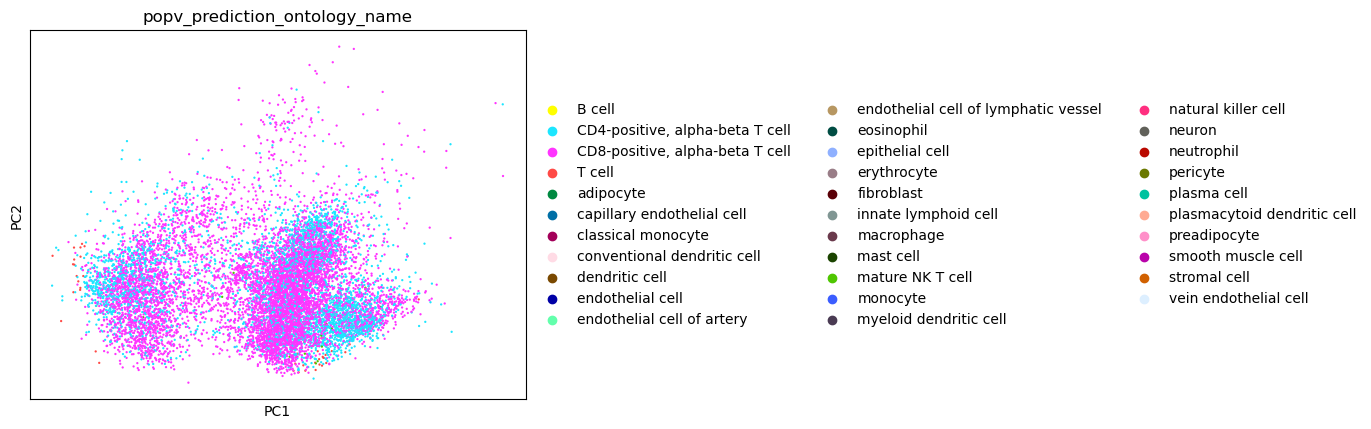

In [42]:
sc.pp.pca(combined_adata)                                               # PCA computation
sc.pl.pca(combined_adata, color="popv_prediction_ontology_name")        # Scatter plot in PCA coordinates

**UMAP plotting**

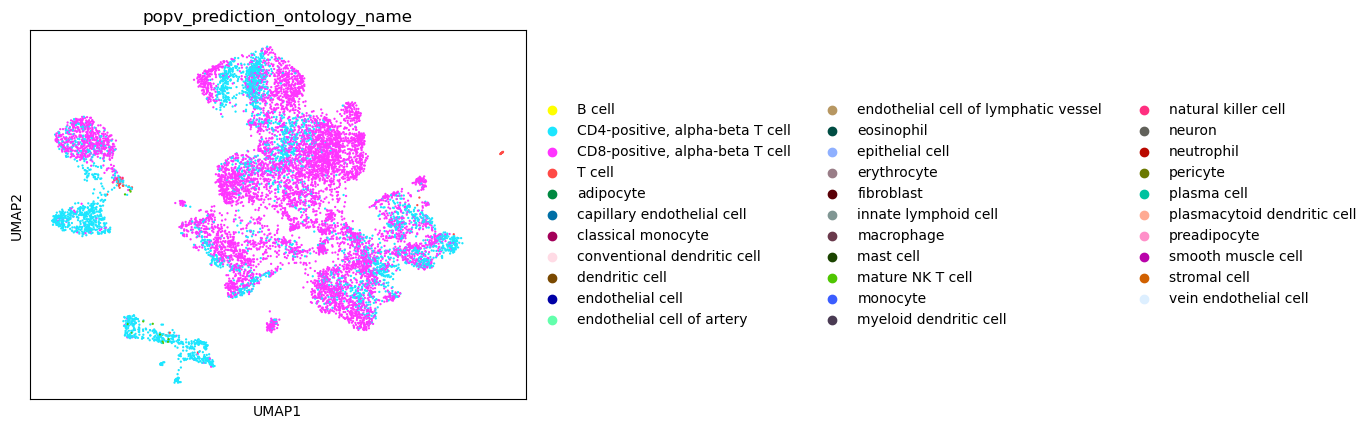

In [44]:
sc.pp.neighbors(combined_adata)
sc.tl.umap(combined_adata)
sc.pl.umap(combined_adata, color="popv_prediction_ontology_name")

In [45]:
combined_adata

AnnData object with n_obs × n_vars = 11165 × 32285
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sam

In [46]:
sc.pp.log1p(combined_adata)                                             # Logarithmic transformation
sc.pp.highly_variable_genes(combined_adata)                             # Annotate highly variable genes
sc.pp.filter_cells(combined_adata, min_genes=3)                         # Filter out cells with less than 3 genes expressed
combined_adata

AnnData object with n_obs × n_vars = 11165 × 32285
    obs: 'soma_joinid', 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'percent.ribo', 'percent.hemoglobin', 'S_score', 'G2M_score', 'cell_cycle_phase', 'gene_gini', 'gene_entropy', 'mt_gini', 'mt_entropy', 'leiden', 'sample_id', 'author_cell_id', 'author_cell_type', 'author_cell_type_cell_ontology_id', 'author_cell_type_cell_ontology_name', 'author_cell_cluster', 'study_id', 'dataset_id', 'sample_name', 'donor_id', 'sample_type', 'sample_collection_method', 'sample_cell_line_name_cellosaurus', 'sample_cell_line_accession_cellosaurus', 'sample_tissue', 'sample_tissue_uberon_name', 'sample_tissue_uberon_id', 'sample_pathology', 'sample_disease', 'sample_disease_id', 'sample_in_vivo_harvest_timepoint', 'sample_treatment', 'sample_treatment_substance', 'sample_treatment_substance_id', 'sample_treatment_dose', 'sample_treatment_dose_unit', 'sample_treatment_timepoint', 'sample_treatment_timepoint_unit', 'sample_biomarkers', 'sam